# 1. Importing require libiraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Importing and understanding the dataset

# Train dataset

In [ ]:
try:
    from google.colab import files  # will fail outside Colab
    uploaded = files.upload()
    print("Uploaded files:", list(uploaded.keys()))
except Exception as e:
    print("If you're in Colab, this will work. Otherwise, skip to Option 2 or load from local path.")

Saving Training set Value.csv to Training set Value.csv
Uploaded files: ['Training set Value.csv']


In [ ]:
csv_path = 'Training set Value.csv'
if csv_path:
    df = pd.read_csv(csv_path)

Shape of the dataset

In [ ]:
df.shape

(59400, 40)

Printing out a few columns

In [ ]:
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


# 3. Exploration Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  object 
 3   funder                 55763 non-null  object 
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  object 
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  object 
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  object 
 11  subvillage             59029 non-null  object 
 12  region                 59400 non-null  object 
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lg

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
id,0
amount_tsh,0
date_recorded,0
funder,3637
gps_height,0
installer,3655
longitude,0
latitude,0
wpt_name,2
num_private,0


In [ ]:
df['funder'] = df.funder.fillna(df.funder.mode()[0])
df['installer'] = df.installer.fillna(df.installer.mode()[0])
df['subvillage'] = df.subvillage.fillna(df.subvillage.mode()[0])
df['public_meeting'] = df.public_meeting.fillna(df.public_meeting.mode()[0]).infer_objects(copy=False)
df['scheme_management'] = df.scheme_management.fillna(df.scheme_management.mode()[0])
df['scheme_name'] = df.scheme_name.fillna(df.scheme_name.mode()[0])
df['permit']= df.permit.fillna(df.permit.mode()[0]).infer_objects(copy=False)

/tmp/ipykernel_9826/1512209040.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['public_meeting'] = df.public_meeting.fillna(df.public_meeting.mode()[0]).infer_objects(copy=False)
/tmp/ipykernel_9826/1512209040.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['permit']= df.permit.fillna(df.permit.mode()[0]).infer_objects(copy=False)


In [ ]:
try:
    from google.colab import files  # will fail outside Colab
    uploaded = files.upload()
    print("Uploaded files:", list(uploaded.keys()))
except Exception as e:
    print("If you're in Colab, this will work. Otherwise, skip to Option 2 or load from local path.")

Saving Training set Label.csv to Training set Label.csv
Uploaded files: ['Training set Label.csv']


In [ ]:
csv_path = 'Training set Label.csv'
if csv_path:
    df2 = pd.read_csv(csv_path)

In [ ]:
df2.head()

,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional


In [ ]:
print(df2.isnull().sum())

id              0
status_group    0
dtype: int64


In [ ]:
df2.duplicated().sum()

np.int64(0)

Merging dataset

In [ ]:
df = df.merge(df2)

Analysing the "target" variable

In [ ]:
df['status_group'].describe()

,status_group
count,59400
unique,3
top,functional
freq,32259


In [ ]:
df['status_group'].unique()

array(['functional', 'non functional', 'functional needs repair'],
      dtype=object)

In [ ]:
# Status_group column has values "functional","non functional" and "functional needs repair"
df['status_group'] = df['status_group'].map({'functional': 0, 'non functional': 1, 'functional needs repair': 2})

In [ ]:
df['status_group'] = df['status_group'].astype('category')

# Categorical summary: counts and percentages
counts = df['status_group'].value_counts()
perc   = df['status_group'].value_counts(normalize=True) * 100

In [ ]:
df.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,0
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,0
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,0
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,1
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,0


Analysing numeric data

In [ ]:
df_num = df.select_dtypes(include=['number']).copy()
df_num.columns

Index(['id', 'amount_tsh', 'gps_height', 'longitude', 'latitude',
       'num_private', 'region_code', 'district_code', 'population',
       'construction_year'],
      dtype='object')

In [ ]:
df_num.drop(columns=['id'], inplace=True)

In [ ]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
amount_tsh,59400.0,317.650385,2997.574558,0.00000,0.000000,0.000000,20.000000,3.500000e+05
gps_height,59400.0,668.297239,693.116350,-90.00000,0.000000,369.000000,1319.250000,2.770000e+03
longitude,59400.0,34.077427,6.567432,0.00000,33.090347,34.908743,37.178387,4.034519e+01
latitude,59400.0,-5.706033,2.946019,-11.64944,-8.540621,-5.021597,-3.326156,-2.000000e-08
num_private,59400.0,0.474141,12.236230,0.00000,0.000000,0.000000,0.000000,1.776000e+03
region_code,59400.0,15.297003,17.587406,1.00000,5.000000,12.000000,17.000000,9.900000e+01
district_code,59400.0,5.629747,9.633649,0.00000,2.000000,3.000000,5.000000,8.000000e+01
population,59400.0,179.909983,471.482176,0.00000,0.000000,25.000000,215.000000,3.050000e+04
construction_year,59400.0,1300.652475,951.620547,0.00000,0.000000,1986.000000,2004.000000,2.013000e+03


In [ ]:
numeric_df = df.select_dtypes(include=['number']).copy()
numeric_df['status_group'] = df['status_group'].astype(int)
corr_matrix = numeric_df.corr()
result = corr_matrix['status_group'].sort_values(ascending=False)
result

,status_group
status_group,1.000000
region_code,0.083590
district_code,0.033979
latitude,0.021020
id,0.003354
num_private,-0.006159
population,-0.015198
amount_tsh,-0.043533
construction_year,-0.056893
longitude,-0.071635


In [ ]:
#Replace zero with missing
df['longitude'] = df['longitude'].replace(0, np.nan)
df['gps_height'] = df['gps_height'].replace(0, np.nan)
df['population'] = df['population'].replace(0, np.nan)

In [ ]:
df['longitude'] = df['longitude'].fillna(df['longitude'].mean())
df['gps_height'] = df['gps_height'].fillna(df['gps_height'].mean())
df['population'] = df['population'].fillna(df['population'].mean())

In [ ]:
df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
amount_tsh,59400.0,317.650385,2997.574558,0.00000,0.000000,0.000000,20.000000,3.500000e+05
gps_height,59400.0,668.297239,693.116350,-90.00000,0.000000,369.000000,1319.250000,2.770000e+03
longitude,59400.0,34.077427,6.567432,0.00000,33.090347,34.908743,37.178387,4.034519e+01
latitude,59400.0,-5.706033,2.946019,-11.64944,-8.540621,-5.021597,-3.326156,-2.000000e-08
num_private,59400.0,0.474141,12.236230,0.00000,0.000000,0.000000,0.000000,1.776000e+03
region_code,59400.0,15.297003,17.587406,1.00000,5.000000,12.000000,17.000000,9.900000e+01
district_code,59400.0,5.629747,9.633649,0.00000,2.000000,3.000000,5.000000,8.000000e+01
population,59400.0,179.909983,471.482176,0.00000,0.000000,25.000000,215.000000,3.050000e+04
construction_year,59400.0,1300.652475,951.620547,0.00000,0.000000,1986.000000,2004.000000,2.013000e+03


Analysing categorical data

In [ ]:
categorical_values = []
for column in df.columns:
    print('==============================')
    print(f"{column} : {df[column].unique()}")
    if len(df[column].unique()) <= 10:
        categorical_values.append(column)

id : [69572  8776 34310 ... 37057 31282 26348]
amount_tsh : [6.00e+03 0.00e+00 2.50e+01 2.00e+01 2.00e+02 5.00e+02 5.00e+01 4.00e+03
 1.50e+03 6.00e+00 2.50e+02 1.00e+01 1.00e+03 1.00e+02 3.00e+01 2.00e+03
 4.00e+02 1.20e+03 4.00e+01 3.00e+02 2.50e+04 7.50e+02 5.00e+03 6.00e+02
 7.20e+03 2.40e+03 5.00e+00 3.60e+03 4.50e+02 4.00e+04 1.20e+04 3.00e+03
 7.00e+00 2.00e+04 2.80e+03 2.20e+03 7.00e+01 5.50e+03 1.00e+04 2.50e+03
 6.50e+03 5.50e+02 3.30e+01 8.00e+03 4.70e+03 7.00e+03 1.40e+04 1.30e+03
 1.00e+05 7.00e+02 1.00e+00 6.00e+01 3.50e+02 2.00e-01 3.50e+01 3.06e+02
 8.50e+03 1.17e+05 3.50e+03 5.20e+02 1.50e+01 6.30e+03 9.00e+03 1.50e+02
 1.20e+05 1.38e+05 3.50e+05 4.50e+03 1.30e+04 4.50e+04 2.00e+00 1.50e+04
 1.10e+04 5.00e+04 7.50e+03 1.63e+04 8.00e+02 1.60e+04 3.00e+04 5.30e+01
 5.40e+03 7.00e+04 2.50e+05 2.00e+05 2.60e+04 1.80e+04 2.60e+01 5.90e+02
 9.00e+02 9.00e+00 1.40e+03 1.70e+05 2.20e+02 3.80e+04 2.50e-01 1.20e+01
 6.00e+04 5.90e+01]
date_recorded : ['2011-03-14' '2013-03-06' '

Applying the hypothesis to understand data and creation of more variables

In [ ]:
# Reset index to make 'status_group' a column again if it's the index
if df.index.name == 'status_group':
    df.reset_index(inplace=True)

# Create the 'is_functional' column based on 'status_group'
# Assuming 'functional' is mapped to 0, so is_functional is True when status_group is 0
df['is_functional'] = (df['status_group'] == 0).astype(int)

pump_type_func = (
    df.groupby('waterpoint_type_group')['is_functional']
      .mean()
      .sort_values(ascending=False)
)

print(pump_type_func)

waterpoint_type_group
dam                   0.857143
cattle trough         0.724138
improved spring       0.718112
hand pump             0.617852
communal standpipe    0.576491
other                 0.131661
Name: is_functional, dtype: float64


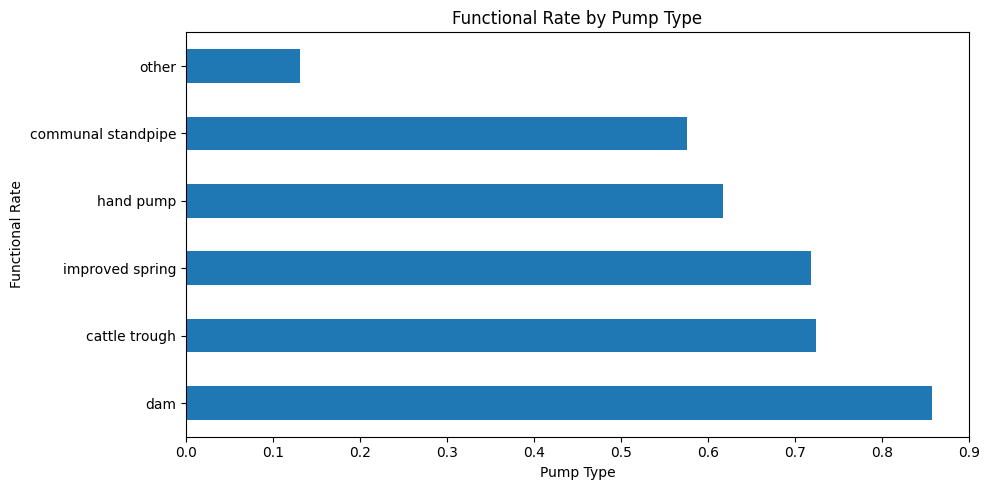

In [ ]:

pump_type_func.plot(kind='barh', figsize=(10,5), title='Functional Rate by Pump Type')
plt.ylabel('Functional Rate')
plt.xlabel('Pump Type')
plt.tight_layout()
plt.show()

In [ ]:
top_installers = df['installer'].value_counts().head(10).index

installer_summary = (
    df[df['installer'].isin(top_installers)]
    .groupby('installer')['is_functional']
    .mean()
    .sort_values(ascending=False)
)

print(installer_summary)

installer
Commu                 0.683019
0                     0.572716
Hesawa                0.565476
DWE                   0.542955
DANIDA                0.516190
KKKT                  0.469933
TCRS                  0.410184
Government            0.293151
Central government    0.270096
RWE                   0.252073
Name: is_functional, dtype: float64


In [ ]:
df['installer'].value_counts().head(10)

,count
installer,
DWE,21057
Government,1825
RWE,1206
Commu,1060
DANIDA,1050
KKKT,898
Hesawa,840
0,777
TCRS,707


In [ ]:
df['installer'] = df['installer'].replace('0', 'Unknown')

top_installers = df['installer'].value_counts().head(10).index

installer_summary = (
    df[df['installer'].isin(top_installers)]
    .groupby('installer')['is_functional']
    .mean()
    .sort_values(ascending=False)
)

print(installer_summary)

installer
Commu                 0.683019
Unknown               0.573077
Hesawa                0.565476
DWE                   0.542955
DANIDA                0.516190
KKKT                  0.469933
TCRS                  0.410184
Government            0.293151
Central government    0.270096
RWE                   0.252073
Name: is_functional, dtype: float64


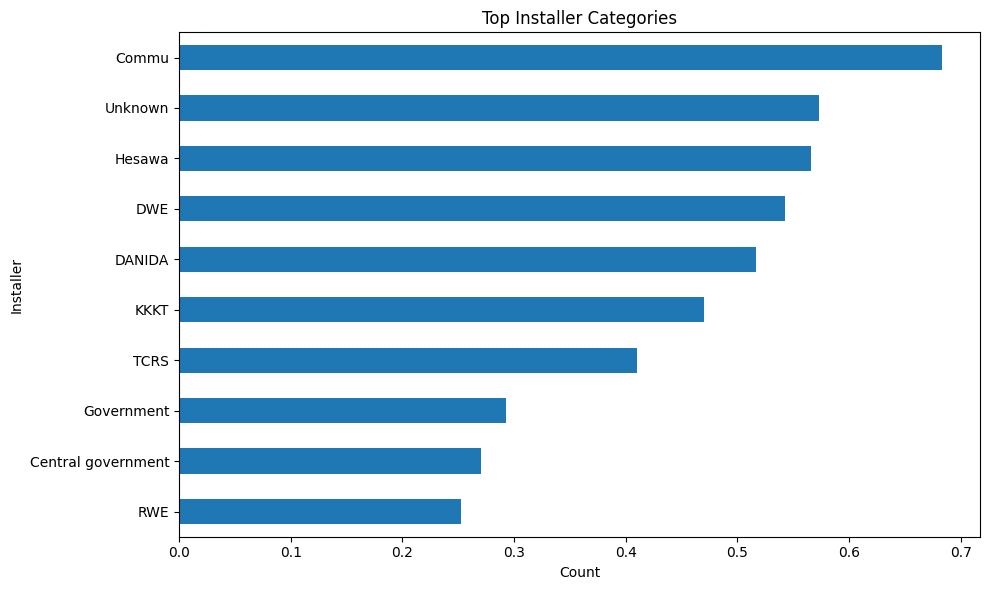

In [ ]:
plt.figure(figsize=(10, 6))
installer_summary.sort_values().plot(kind='barh')
plt.title('Top Installer Categories')
plt.xlabel('Count')
plt.ylabel('Installer')
plt.tight_layout()
plt.show()

In [ ]:
summary = (
    df.groupby('region')
      .agg(
          n=('is_functional', 'size'),
          func_rate=('is_functional', 'mean')
      )
      .query('n >= 10')
      .sort_values('func_rate', ascending=False)
)

print(summary)

                  n  func_rate
region                        
Iringa         5294   0.782206
Arusha         3350   0.684776
Manyara        1583   0.623500
Kilimanjaro    4379   0.602877
Pwani          2635   0.590512
Dar es Salaam   805   0.572671
Tanga          2547   0.563801
Ruvuma         2640   0.560606
Shinyanga      4982   0.559815
Morogoro       4006   0.528957
Kagera         3316   0.520808
Mbeya          4639   0.499892
Mwanza         3102   0.484204
Kigoma         2816   0.484020
Singida        2093   0.483039
Dodoma         2201   0.458428
Mara           1969   0.449975
Tabora         1959   0.432874
Rukwa          1808   0.391040
Mtwara         1730   0.302890
Lindi          1546   0.297542


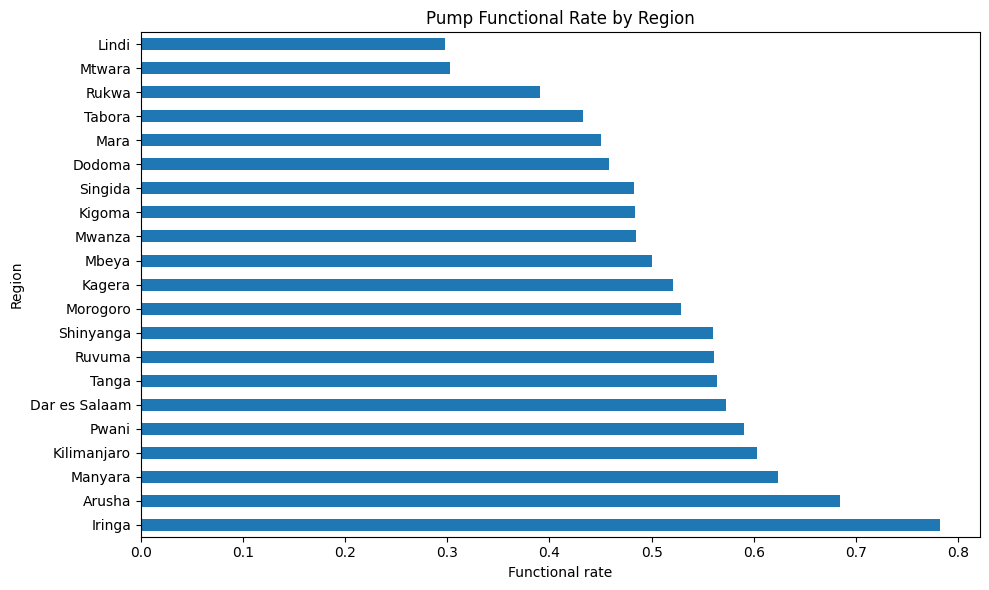

In [ ]:
summary['func_rate'].plot(kind='barh', figsize=(10, 6))
plt.xlabel('Functional rate')
plt.ylabel('Region')
plt.title('Pump Functional Rate by Region')
plt.tight_layout()
plt.show()

In [ ]:
# Create age feature (assuming current year is 2026)
df['age'] = 2026 - df['construction_year']

# Correlation between age and functionality
correlation = df['age'].corr(df['is_functional'])
print(f"Correlation: {correlation:.3f}")

Correlation: -0.051


In [ ]:
# Find actual age range first
print(df['age'].describe())

# Create bins starting from actual minimum (likely around 11)
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 11, 15, 20, 30, 50],
                         labels=['0-11', '12-15', '16-20', '21-30', '30+'])

age_reliability = (
    df.groupby('age_group', observed=True)['is_functional']
      .agg(['mean', 'size'])
      .round(3)
)

print(age_reliability)

count    59400.000000
mean       725.347525
std        951.620547
min         13.000000
25%         22.000000
50%         40.000000
75%       2026.000000
max       2026.000000
Name: age, dtype: float64
            mean   size
age_group              
12-15      0.704   2516
16-20      0.701  10849
21-30      0.601  10526
30+        0.432  11701


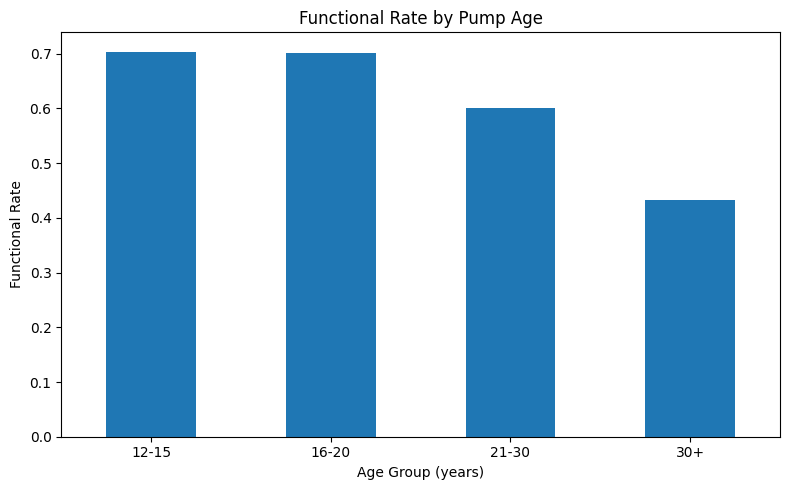

In [ ]:
age_reliability['mean'].plot(kind='bar', figsize=(8,5))
plt.title('Functional Rate by Pump Age')
plt.ylabel('Functional Rate')
plt.xlabel('Age Group (years)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Create population groups
df['pop_group'] = pd.cut(df['population'],
                         bins=[0, 200, 500, 1000, 5000, df['population'].max()],
                         labels=['0-200', '201-500', '501-1000', '1001-5000', '5000+'])

pop_reliability = (
    df.groupby('pop_group', observed=True)['is_functional']
      .agg(['mean', 'size'])
      .round(3)
)

print(pop_reliability)

            mean   size
pop_group              
0-200      0.571  22794
201-500    0.520  31978
501-1000   0.545   3216
1001-5000  0.591   1309
5000+      0.670    103


In [ ]:
# Direct correlation (log population to handle skewness)
df['log_pop'] = np.log1p(df['population'])
correlation = df['log_pop'].corr(df['is_functional'])
print(f"Correlation between log(population) and functional: {correlation:.3f}")

Correlation between log(population) and functional: 0.040


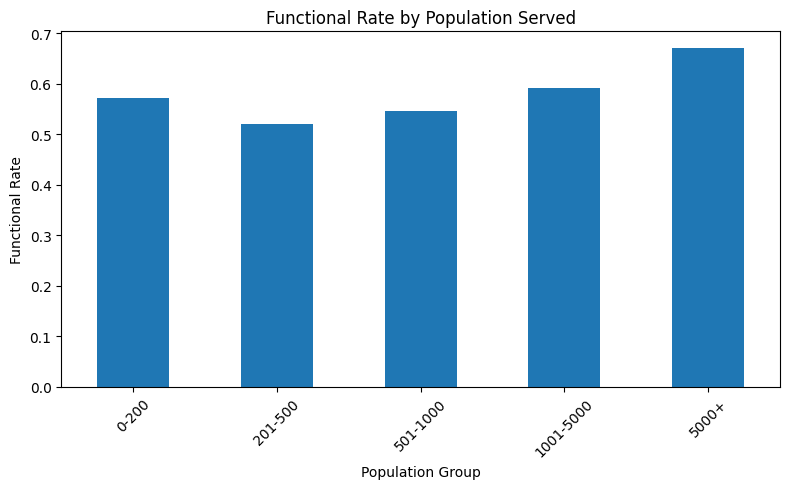

In [ ]:
pop_reliability['mean'].plot(kind='bar', figsize=(8,5))
plt.title('Functional Rate by Population Served')
plt.ylabel('Functional Rate')
plt.xlabel('Population Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
water_quality_reliability = (
    df.groupby('water_quality')['is_functional']
      .agg(['mean', 'size'])
      .round(3)
      .sort_values('mean', ascending=False)
)

print(water_quality_reliability)

                     mean   size
water_quality                   
fluoride            0.755    200
soft                0.566  50818
milky               0.545    804
salty abandoned     0.513    339
coloured            0.502    490
salty               0.457   4856
fluoride abandoned  0.353     17
unknown             0.141   1876


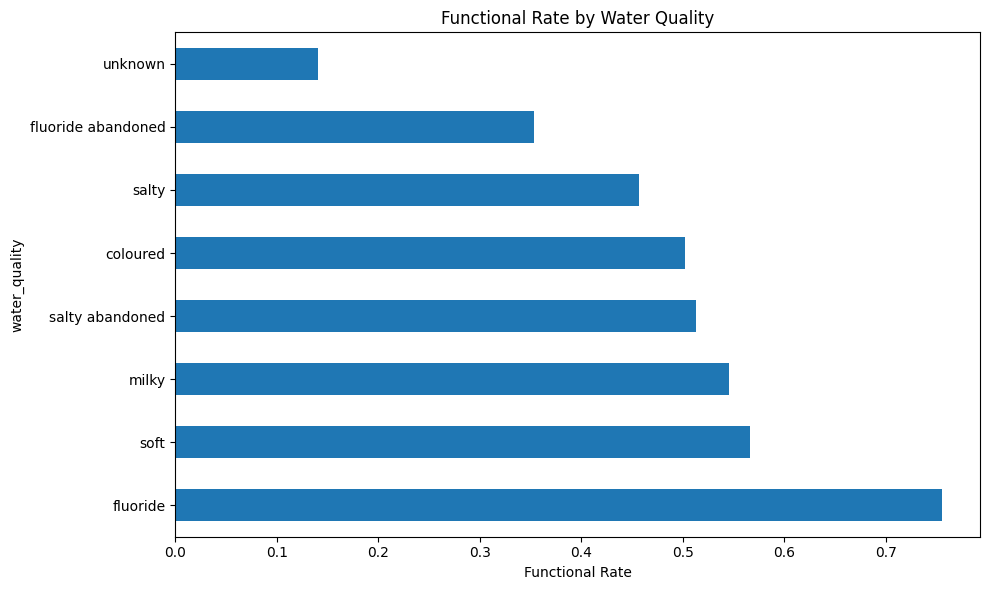

In [ ]:
water_quality_reliability['mean'].plot(kind='barh', figsize=(10,6))
plt.title('Functional Rate by Water Quality')
plt.xlabel('Functional Rate')
plt.tight_layout()
plt.show()

In [ ]:
# Use quality_group (more granular)
quality_reliability = (
    df.groupby('quality_group')['is_functional']
      .agg(['mean', 'size'])
      .round(3)
      .sort_values('mean', ascending=False)
)

print(quality_reliability)

                mean   size
quality_group              
fluoride       0.724    217
good           0.566  50818
milky          0.545    804
colored        0.502    490
salty          0.461   5195
unknown        0.141   1876


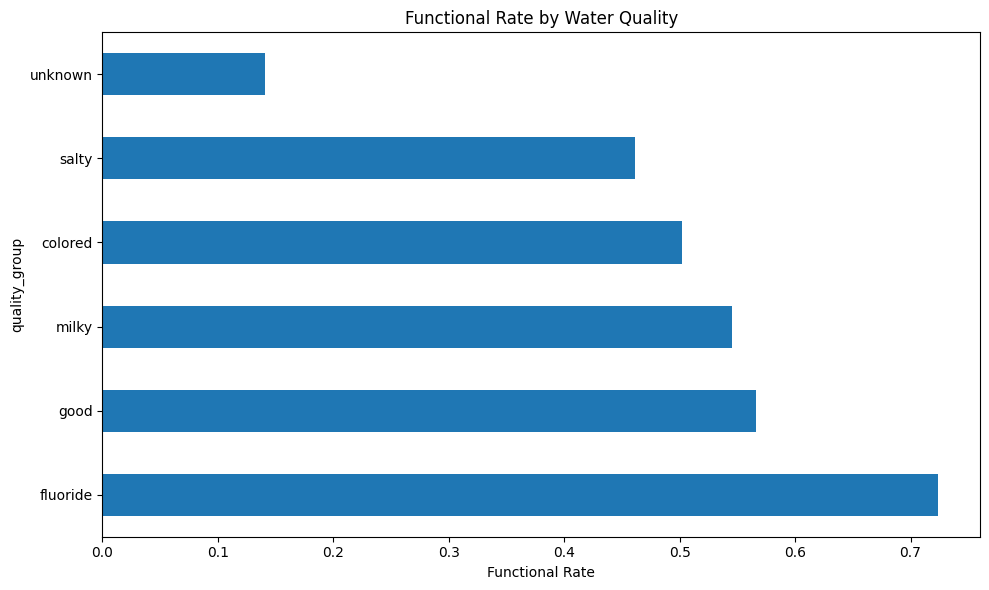

In [ ]:
quality_reliability['mean'].plot(kind='barh', figsize=(10,6))
plt.title('Functional Rate by Water Quality')
plt.xlabel('Functional Rate')
plt.tight_layout()
plt.show()

In [ ]:
funder_reliability = (
    df.groupby('funder')['is_functional']
      .agg(['mean', 'size'])
      .round(3)
      .query('size >= 50')  # Filter small groups
      .sort_values('mean', ascending=False)
)

print(funder_reliability.head(15))

                          mean  size
funder                              
Magadini-makiwaru Water  0.977   175
Ces(gmbh)                0.962   260
St                       0.944    54
Solidarm                 0.943    53
Lawatefuka Water Supply  0.933   180
Oikos E.Afrika           0.923   155
Mkinga  Distric Cou      0.919    62
Losaa-kia Water Supply   0.919    62
Twe                      0.897    97
Ces (gmbh)               0.885   165
Wua                      0.884   121
Germany Republi          0.882   610
Rc Ch                    0.875    80
Rc                       0.865   230
Dmdd                     0.860   186


In [ ]:
top_funders = (
    df[df['funder'].isin(df['funder'].value_counts().head(10).index)]
    .groupby('funder')['is_functional']
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

print(top_funders)

funder
World Vision              0.596
Rwssp                     0.586
Unicef                    0.568
Tasaf                     0.562
Kkkt                      0.562
Danida                    0.550
District Council          0.448
Government Of Tanzania    0.448
Hesawa                    0.425
World Bank                0.404
Name: is_functional, dtype: float64


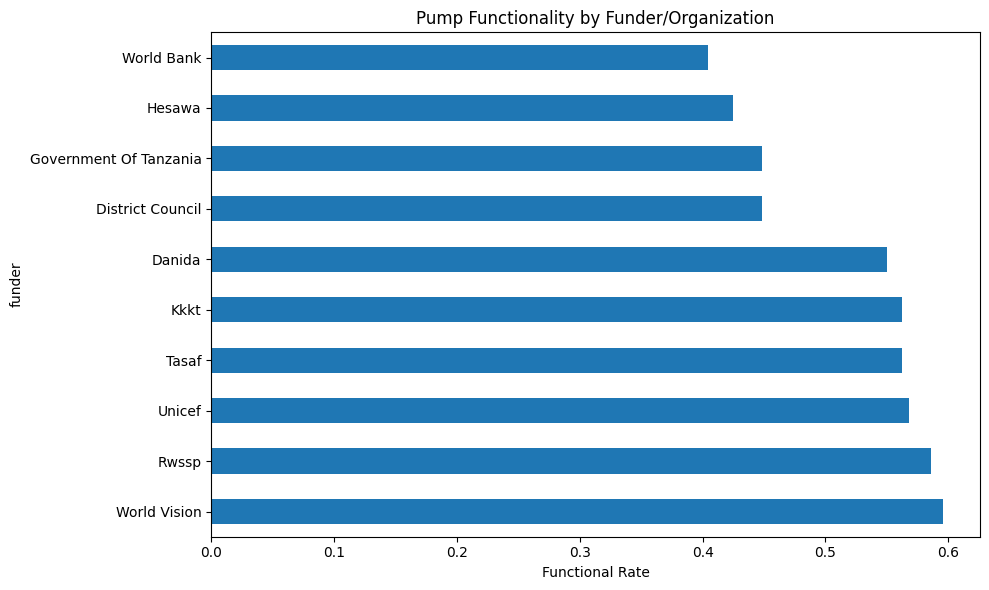

In [ ]:
top_funders.plot(kind='barh', figsize=(10,6))
plt.title('Pump Functionality by Funder/Organization')
plt.xlabel('Functional Rate')
plt.tight_layout()
plt.show()